<a href="https://colab.research.google.com/github/gismo-o/ai-sigorta-projesi/blob/main/health_insurance_ai_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **VERİYİ TANIYALIM**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Veri setini yükleyelim
df = pd.read_csv('insurance.csv')

# İlk 5 satıra bakalım
print("--- İlk 5 Satır ---")
print(df.head())

# Veri seti hakkında genel bilgi (Eksik veri var mı?)
print("\n--- Veri Bilgisi ---")
print(df.info())

# Sayısal sütunların istatistiksel özeti
print("\n--- İstatistiksel Özet ---")
print(df.describe())

--- İlk 5 Satır ---
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

--- Veri Bilgisi ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

--- İstatistiksel Özet ---
               age   

# **AYKIRI DEĞER ANALİZİ**

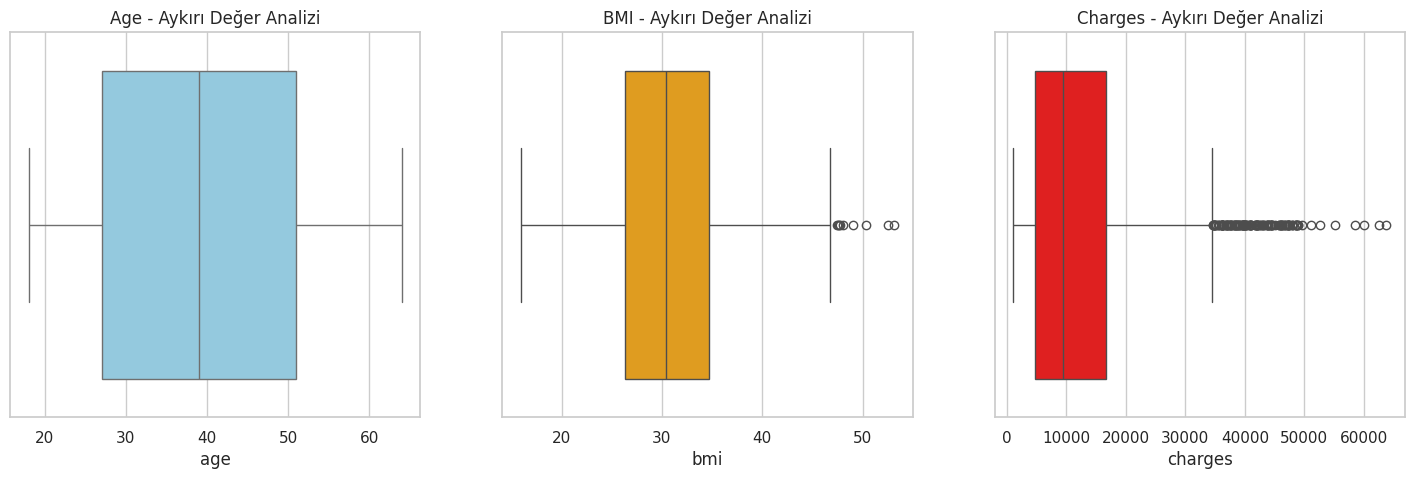

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Görselleştirme stili
sns.set(style="whitegrid")

# 3 Sayısal değişken için Boxplot çizelim (age, bmi, charges)
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Yaş (Age)
sns.boxplot(x=df['age'], ax=ax[0], color='skyblue')
ax[0].set_title('Age - Aykırı Değer Analizi')

# BMI
sns.boxplot(x=df['bmi'], ax=ax[1], color='orange')
ax[1].set_title('BMI - Aykırı Değer Analizi')

# Masraflar (Charges)
sns.boxplot(x=df['charges'], ax=ax[2], color='red')
ax[2].set_title('Charges - Aykırı Değer Analizi')

plt.show()

# **KEŞİFCİ VERİ ANALİZİ (EDA)**

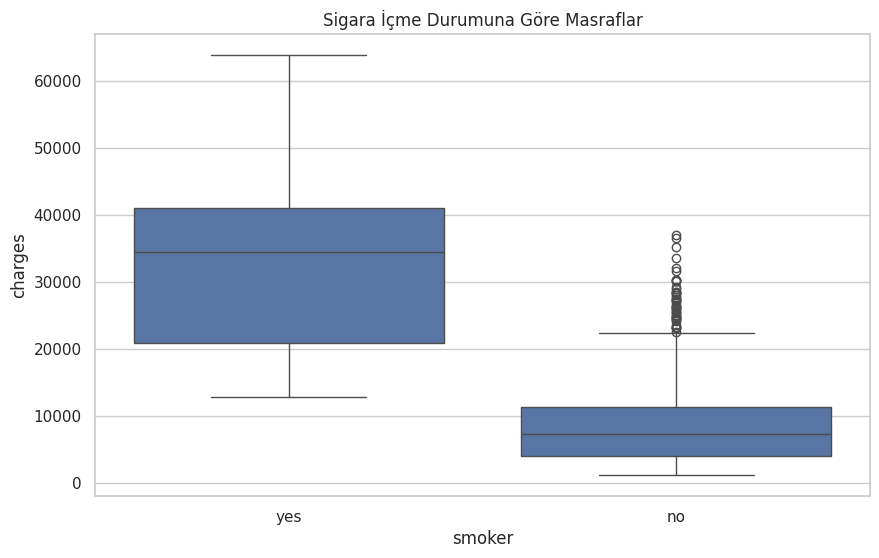

In [3]:
# Sigara içen ve içmeyenlere göre masraf dağılımı
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Sigara İçme Durumuna Göre Masraflar")
plt.show()

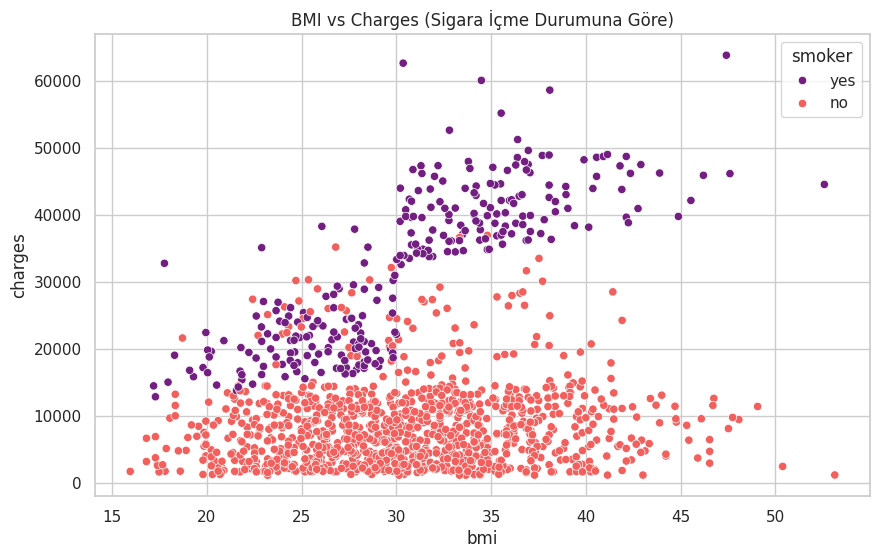

In [4]:
# BMI ve Charges ilişkisini, Sigara ve Obezite durumuna göre renklendirelim
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df, palette='magma')
plt.title("BMI vs Charges (Sigara İçme Durumuna Göre)")
plt.show()

**EDA**

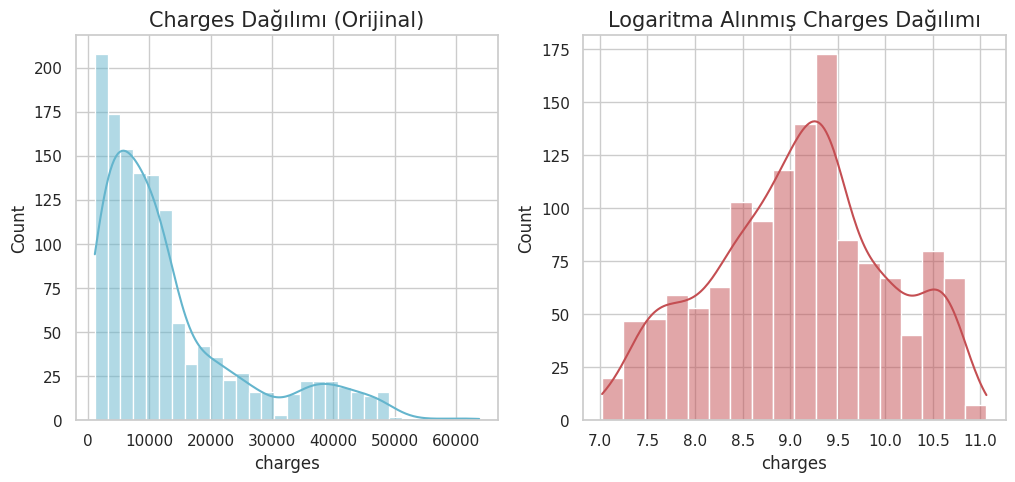

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Charges (Masraflar) Dağılımı
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='c')
plt.title('Charges Dağılımı (Orijinal)', fontsize=15)

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['charges']), kde=True, color='r')
plt.title('Logaritma Alınmış Charges Dağılımı', fontsize=15)

plt.show()

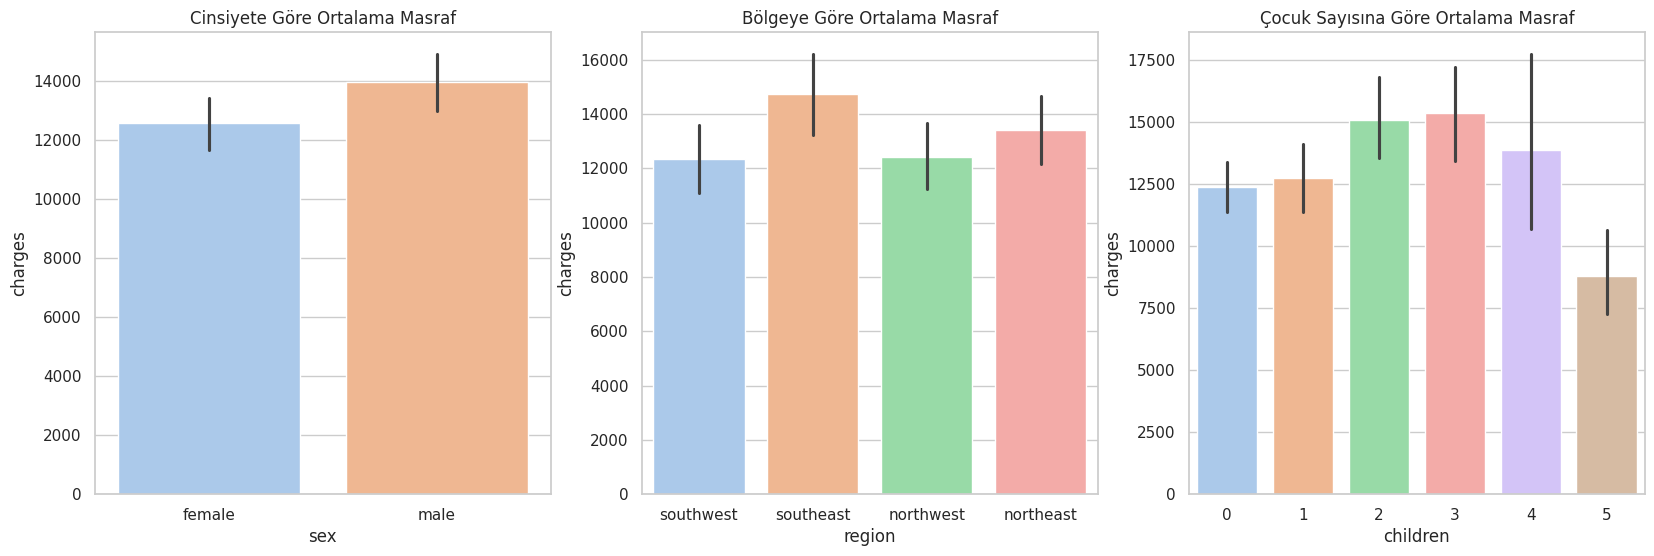

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Cinsiyete Göre Ortalama Masraf
sns.barplot(x='sex', y='charges', data=df, ax=ax[0], palette='pastel')
ax[0].set_title('Cinsiyete Göre Ortalama Masraf')

# Bölgeye Göre Ortalama Masraf
sns.barplot(x='region', y='charges', data=df, ax=ax[1], palette='pastel')
ax[1].set_title('Bölgeye Göre Ortalama Masraf')

# Çocuk Sayısına Göre Ortalama Masraf
sns.barplot(x='children', y='charges', data=df, ax=ax[2], palette='pastel')
ax[2].set_title('Çocuk Sayısına Göre Ortalama Masraf')

plt.show()

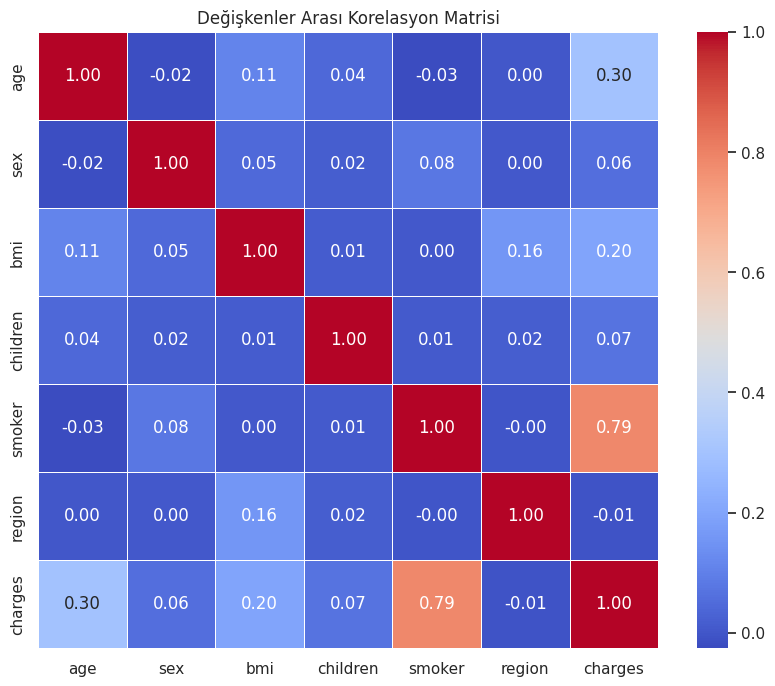

In [7]:
# Korelasyon için geçici bir kopya oluşturup kategorikleri sayıya çevirelim
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
df_corr['region'] = df_corr['region'].astype('category').cat.codes # Hızlıca sayıya çevir

# Korelasyon Matrisi
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Değişkenler Arası Korelasyon Matrisi")
plt.show()

# **İstatistiksel Analiz**

In [8]:
# Sigaranın Etkisi (T-Test)
from scipy import stats

# Veriyi ayıralım
smoker_charges = df[df['smoker'] == 'yes']['charges']
nonsmoker_charges = df[df['smoker'] == 'no']['charges']

# T-Testi Uygulayalım
t_stat, p_value = stats.ttest_ind(smoker_charges, nonsmoker_charges)

print("--- İSTATİSTİKSEL HİPOTEZ TESTİ (T-TEST) ---")
print(f"T-İstatistiği: {t_stat:.4f}")
print(f"P-Değeri      : {p_value:.30f}") # Virgülden sonra 30 hane göster

if p_value < 0.05:
    print("\nSONUÇ: H0 Reddedildi. Fark İSTATİSTİKSEL OLARAK ANLAMLI.")
    print("Yorum: Sigara içen ve içmeyenlerin masrafları arasında şans eseri olamayacak kadar kesin bir fark var.")
else:
    print("\nSONUÇ: Fark anlamsız. Şans eseri olabilir.")

--- İSTATİSTİKSEL HİPOTEZ TESTİ (T-TEST) ---
T-İstatistiği: 46.6649
P-Değeri      : 0.000000000000000000000000000000

SONUÇ: H0 Reddedildi. Fark İSTATİSTİKSEL OLARAK ANLAMLI.
Yorum: Sigara içen ve içmeyenlerin masrafları arasında şans eseri olamayacak kadar kesin bir fark var.


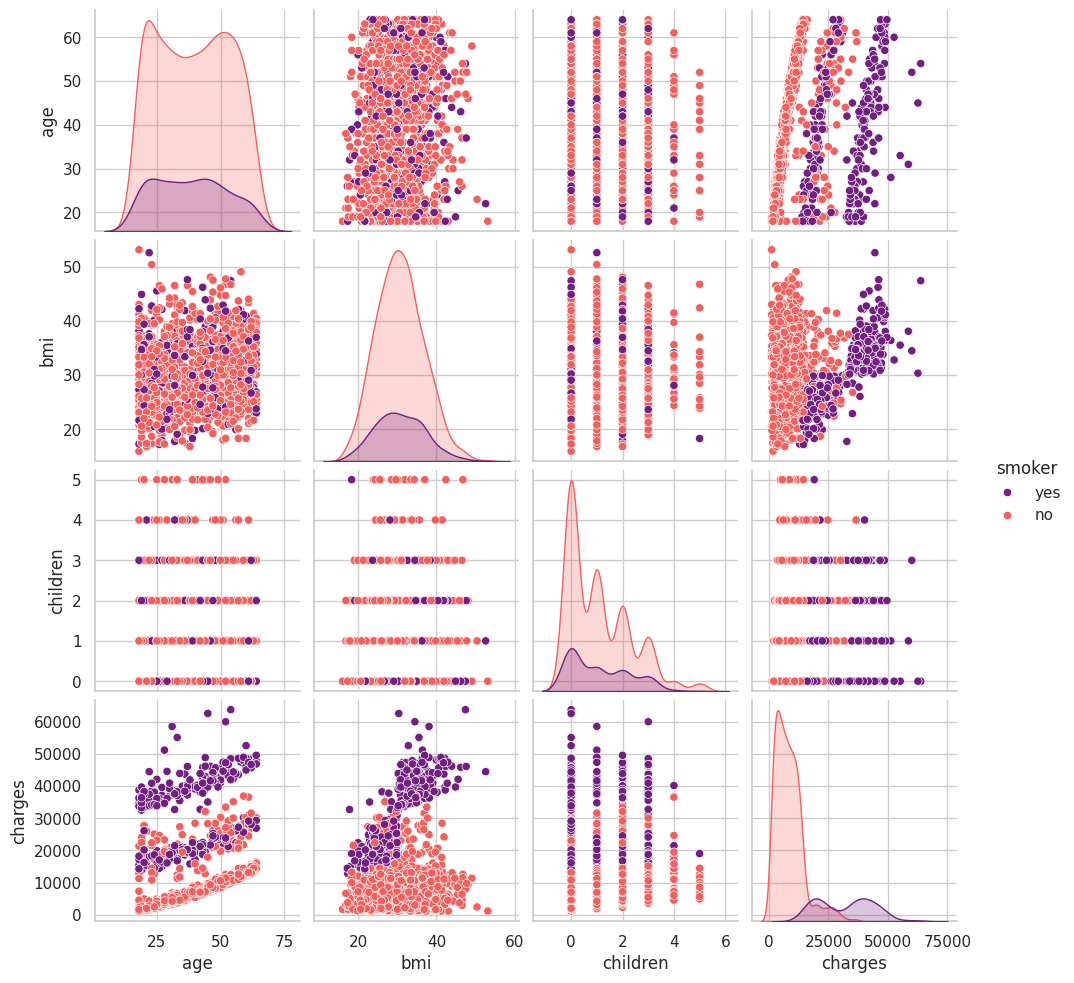

In [9]:
# Sadece sayısal sütunları ve smoker bilgisini alıp çizdirelim
sns.pairplot(df, hue='smoker', palette='magma', vars=['age', 'bmi', 'children', 'charges'])
plt.show()

# **ENCODING**

In [10]:
df_encoded = df.copy()

# Binary Değişkenler için Manuel Mapping
# Smoker: yes=1, no=0
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

# Sex: male=1, female=0
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})

# Nominal Değişkenler için One-Hot Encoding
# Region sütununu parçalıyoruz ve ilk sütunu düşürüyoruz (drop_first=True)
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True, dtype=int)

# SONUÇ KONTROLÜ
print("--- Encoding Sonrası Sütunlar ---")
print(df_encoded.columns.tolist())
print("\n--- İlk 5 Satır ---")
print(df_encoded.head())

# Korelasyonu tekrar kontrol edelim
print("\n--- Yeni Korelasyonlar (Charges ile) ---")
print(df_encoded.corr()['charges'].sort_values(ascending=False))

--- Encoding Sonrası Sütunlar ---
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

--- İlk 5 Satır ---
   age  sex     bmi  children  smoker      charges  region_northwest  \
0   19    0  27.900         0       1  16884.92400                 0   
1   18    1  33.770         1       0   1725.55230                 0   
2   28    1  33.000         3       0   4449.46200                 0   
3   33    1  22.705         0       0  21984.47061                 1   
4   32    1  28.880         0       0   3866.85520                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  

--- Yeni Korelasyonlar (Charges ile) ---
charges             1.000000
smoker              0.787251
age                 0.299008
bmi                 0.198341

## **Veri Bölme (Split), Log Dönüşümü ve Ölçekleme (Scaling)**

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Interaction Term (Etkileşim Terimi)
# BMI'ın etkisi sigara içenlerde katlandığı için bu özelliği elle üretiyoruz
df_encoded['bmi_smoker'] = df_encoded['bmi'] * df_encoded['smoker']

# X ve y Ayrımı
X = df_encoded.drop('charges', axis=1) # Özellikler
y = df_encoded['charges']              # Hedef (Target)

# Hedef Değişken Log Dönüşümü (Normal Dağılıma Yaklaştırma)
# Model eğitimi log alınmış verilerle yapılacak!
y_log = np.log1p(y)

# Train - Test Split (%80 Eğitim, %20 Test)
# random_state=42 (Sonuçlarımızın aynı çıkması için sabitliyoruz)
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# Scaling (Ölçekleme)
# Sadece X verilerini ölçekleriz (Target'a scaling yapılmaz, zaten log aldık)
scaler = StandardScaler()

# Scaler'ı sadece Train setine "fit" ederiz
# Test setini ise sadece "transform" ederiz (Train'den öğrendiği kuralları uygular).
# "Data Leakage" (Veri Sızıntısı) önlemi
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Sonuçları Kontrol Edelim
print(f"Eğitim Seti Boyutu: {X_train_scaled.shape}")
print(f"Test Seti Boyutu  : {X_test_scaled.shape}")
print("\n--- Yeni Özellik Listesi (Sırasıyla) ---")
print(X.columns.tolist())
print("\n--- İlk Eğitim Verisi Örneği (Scaled) ---")
print(X_train_scaled[0])

Eğitim Seti Boyutu: (1070, 9)
Test Seti Boyutu  : (268, 9)

--- Yeni Özellik Listesi (Sırasıyla) ---
['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest', 'bmi_smoker']

--- İlk Eğitim Verisi Örneği (Scaled) ---
[ 0.47222651 -1.0246016  -1.75652513  0.73433626 -0.50874702  1.78316783
 -0.59966106 -0.5723141  -0.49598743]


# **MODELLEME - Çoklu Model Eğitimi (Model Comparison)**

In [12]:
!pip install catboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from IPython.display import display

# MODELLERİN TANIMLANMASI
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.1, verbose=0, random_state=42)
}

results = []

print("--- 6 FARKLI MODEL YARIŞTIRILIYOR ---\n")

# EĞİTİM VE TAHMİN DÖNGÜSÜ
for name, model in models.items():
    # Eğit
    model.fit(X_train_scaled, y_train_log)

    # Tahmin Et
    y_pred_log = model.predict(X_test_scaled)

    # Ters Dönüşüm (Log -> Gerçek Dolar)
    y_pred_orig = np.expm1(y_pred_log)
    y_test_orig = np.expm1(y_test_log)

    # Skorla
    r2 = r2_score(y_test_orig, y_pred_orig)
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))

    results.append({"Model": name, "R2 Score": r2, "MAE ($)": mae, "RMSE": rmse})
    print(f" {name:<20} R2: {r2:.4f}")

# DataFrame Oluştur ve Sırala
df_results = pd.DataFrame(results).sort_values(by="R2 Score", ascending=False)

# Renklendirme Fonksiyonları
def highlight_best(s):
    # R2 Score için En Yüksek (Max) değer>>yeşil
    is_max = s == s.max()
    return ['background-color: #d6f5d6; color: black; font-weight: bold' if v else '' for v in is_max]

def highlight_worst(s):
    # Hata oranları (MAE, RMSE) için En Düşük (Min) değer yeşil olsun
    is_min = s == s.min()
    return ['background-color: #d6f5d6; color: black; font-weight: bold' if v else '' for v in is_min]

# Tabloyu Formatla ve Boya
styled_table = df_results.style.format({
    'R2 Score': '{:.4f}',
    'MAE ($)': '${:,.2f}',
    'RMSE': '{:,.2f}'
}).apply(highlight_best, subset=['R2 Score']) \
  .apply(highlight_worst, subset=['MAE ($)', 'RMSE']) \
  .background_gradient(subset=['R2 Score'], cmap='Blues') \
  .background_gradient(subset=['MAE ($)'], cmap='Reds') \
  .set_properties(**{'border': '1px solid black', 'text-align': 'center'})

# Tabloyu Ekrana Bas
display(styled_table)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.3 MB/s eta 0:00:00
--- 6 FARKLI MODEL YARIŞTIRILIYOR ---

 Linear Regression    R2: 0.5280
 Ridge Regression     R2: 0.5365
 Random Forest        R2: 0.8763
 XGBoost              R2: 0.8565
 LightGBM             R2: 0.8710
 CatBoost             R2: 0.8735


,Model,R2 Score,MAE ($),RMSE
2,Random Forest,0.8763,"$2,088.49","4,382.00"
5,CatBoost,0.8735,"$2,053.86","4,432.40"
4,LightGBM,0.8710,"$2,182.13","4,475.45"
3,XGBoost,0.8565,"$2,218.69","4,719.93"
1,Ridge Regression,0.5365,"$3,956.05","8,483.02"
0,Linear Regression,0.5280,"$3,974.49","8,559.98"


# **Model Performansını Karşılaştırma**

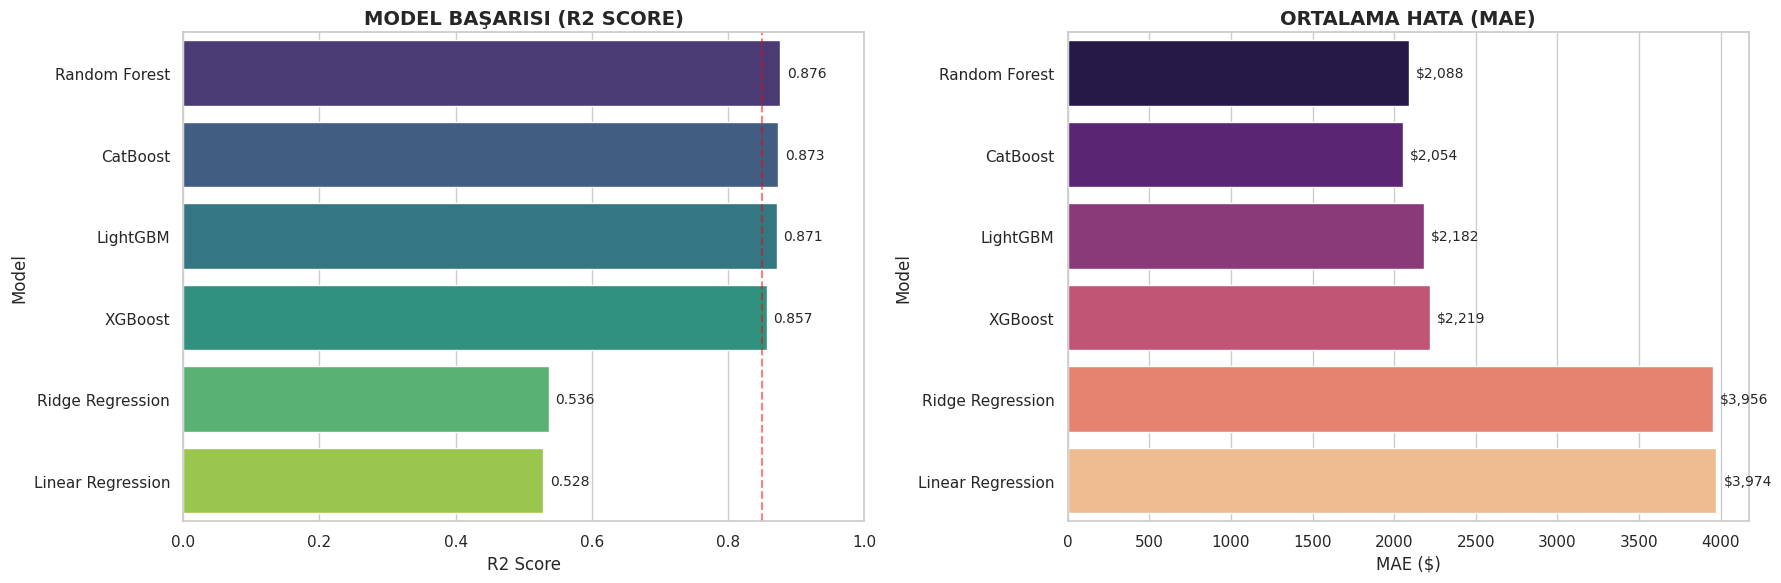

In [13]:
# GÖRSEL DASHBOARD (GRAFİKLER)
plt.figure(figsize=(18, 6))

# Grafik 1: R2 Score (Büyük İyi)
plt.subplot(1, 2, 1)
ax1 = sns.barplot(x='R2 Score', y='Model', data=df_results, palette='viridis')
plt.title('MODEL BAŞARISI (R2 SCORE)', fontsize=14, fontweight='bold')
plt.xlim(0, 1.0)
plt.axvline(0.85, color='red', linestyle='--', alpha=0.5) # %85 Baraj Çizgisi
for i in ax1.containers:
    ax1.bar_label(i, fmt='%.3f', padding=5, fontsize=10)

# Grafik 2: MAE
plt.subplot(1, 2, 2)
ax2 = sns.barplot(x='MAE ($)', y='Model', data=df_results, palette='magma')
plt.title('ORTALAMA HATA (MAE)', fontsize=14, fontweight='bold')
for i in ax2.containers:
    ax2.bar_label(i, fmt='${:,.0f}', padding=5, fontsize=10)

plt.tight_layout()
plt.show()

# **VOTING MODEL PERFORMANSI**

In [14]:
from sklearn.ensemble import VotingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
# En iyi 3 modeli seç
model1 = RandomForestRegressor(random_state=42)
model2 = XGBRegressor(random_state=42)
model3 = CatBoostRegressor(verbose=0, random_state=42)

# Güçlerini birleştir
voting_model = VotingRegressor(estimators=[
    ('rf', model1), ('xgb', model2), ('cat', model3)
])

voting_model.fit(X_train_scaled, y_train_log)

# Tahmin Yap (Log cinsinden)
y_pred_vote_log = voting_model.predict(X_test_scaled)

# Log Dönüşümünü Geri Al (Gerçek Dolara Çevir)
y_pred_vote = np.expm1(y_pred_vote_log)
y_test_orig = np.expm1(y_test_log)

# Metrikleri Hesapla
r2_vote = r2_score(y_test_orig, y_pred_vote)
mae_vote = mean_absolute_error(y_test_orig, y_pred_vote)
rmse_vote = np.sqrt(mean_squared_error(y_test_orig, y_pred_vote))

print(" VOTING REGRESSOR (Güç Birliği) SONUÇLARI")
print(f"R2 Score (Başarı): {r2_vote:.4f}")
print(f"MAE (Ortalama Hata): ${mae_vote:.2f}")
print(f"RMSE: {rmse_vote:.2f}")

 VOTING REGRESSOR (Güç Birliği) SONUÇLARI
R2 Score (Başarı): 0.8680
MAE (Ortalama Hata): $2177.17
RMSE: 4526.94


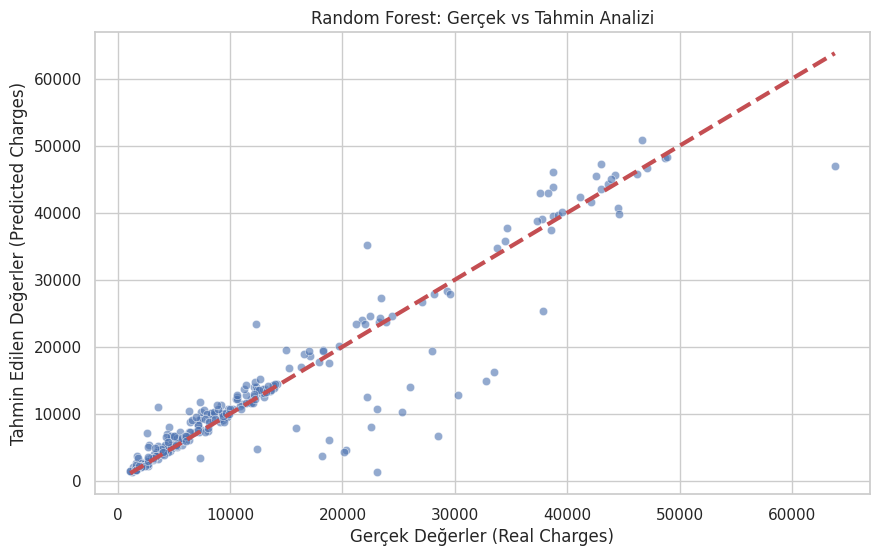

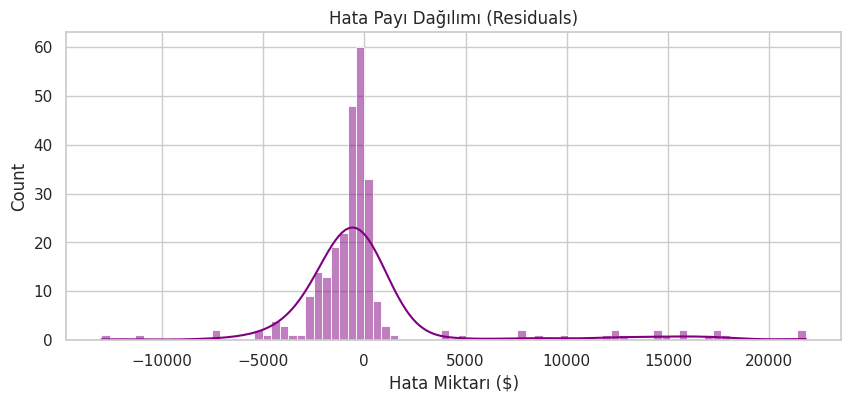

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Şampiyon Modeli (Random Forest) Tekrar Eğitelim
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_log)
y_pred_log = rf_model.predict(X_test_scaled)

# Geri Dönüşüm (Log'dan normale)
y_pred = np.expm1(y_pred_log)
y_test = np.expm1(y_test_log)

# Görselleştirme: Gerçek vs Tahmin
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=3) # Mükemmel tahmin çizgisi
plt.xlabel('Gerçek Değerler (Real Charges)')
plt.ylabel('Tahmin Edilen Değerler (Predicted Charges)')
plt.title('Random Forest: Gerçek vs Tahmin Analizi')
plt.show()

# Hata Dağılımı (Residuals)
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
sns.histplot(residuals, kde=True, color='purple')
plt.title("Hata Payı Dağılımı (Residuals)")
plt.xlabel("Hata Miktarı ($)")
plt.show()

LİNEAR TABANLI MODELLERİN KARŞILAŞTIRILMASI

In [16]:
from sklearn.linear_model import Lasso, ElasticNet

# Linear Tabanlı Modelleri Kıyaslayalım
linear_models = {
    "Linear Regression (Normal)": LinearRegression(),
    "Ridge (L2 Regularization)": Ridge(alpha=1.0),
    "Lasso (L1 Regularization)": Lasso(alpha=0.001), # Alpha çok küçük seçilmeli
    "Elastic Net (L1 + L2)": ElasticNet(alpha=0.001, l1_ratio=0.5)
}

print("LINEAR MODELLER (L1 vs L2)\n")

for name, model in linear_models.items():
    model.fit(X_train_scaled, y_train_log)
    y_pred_log = model.predict(X_test_scaled)

    # Geri Dönüşüm
    y_pred = np.expm1(y_pred_log)
    y_test = np.expm1(y_test_log)

    r2 = r2_score(y_test, y_pred)
    print(f"{name:<30} -> R2 Score: {r2:.4f}")

LINEAR MODELLER (L1 vs L2)

Linear Regression (Normal)     -> R2 Score: 0.5280
Ridge (L2 Regularization)      -> R2 Score: 0.5365
Lasso (L1 Regularization)      -> R2 Score: 0.5337
Elastic Net (L1 + L2)          -> R2 Score: 0.5358


# **Hyperparameter Tuning - Hiperparametre Optimizasyonu**

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import numpy as np

# Parametre Izgarası
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search Başlat
rf_grid = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                       param_grid=param_grid,
                       cv=5,
                       scoring='r2',
                       n_jobs=-1,
                       verbose=1)

rf_grid.fit(X_train_scaled, y_train_log)

# Sonuçları Görelim
print("\n--- EN İYİ PARAMETRELER ---")
print(rf_grid.best_params_)

print("\n--- OPTİMİZE EDİLMİŞ BAŞARI SKORU (R2) ---")
best_rf_model = rf_grid.best_estimator_
y_pred_tuned_log = best_rf_model.predict(X_test_scaled)
y_pred_tuned = np.expm1(y_pred_tuned_log) # Log'u geri al
y_test_orig = np.expm1(y_test_log)

print(f"Optimize R2 Score: {r2_score(y_test_orig, y_pred_tuned):.5f}")
print(f"Eski Skor        : 0.87631")
print(f"Fark             : {r2_score(y_test_orig, y_pred_tuned) - 0.87631:.5f}")

best_rf_model = rf_grid.best_estimator_

Fitting 5 folds for each of 81 candidates, totalling 405 fits

--- EN İYİ PARAMETRELER ---
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

--- OPTİMİZE EDİLMİŞ BAŞARI SKORU (R2) ---
Optimize R2 Score: 0.87743
Eski Skor        : 0.87631
Fark             : 0.00112


# **K-Fold Cross Validation**

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Pipeline ile CV
# GridSearch'ten bulduğumuz "best_params_" değerlerini buraya yazıyoruz.
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42))
])

# Pipeline kullandığımız için HAM VERİYİ (X_train) veriyoruz.
cv_scores = cross_val_score(pipeline, X_train, y_train_log, cv=5, scoring='r2')

print("\n--- SONUÇLAR ---")
print(f"Çapraz Doğrulama Ortalaması       : {cv_scores.mean():.4f}")
print(f"Güven Aralığı (Standart Sapma)    : +/- {cv_scores.std():.4f}")

if cv_scores.mean() > 0.80:
    print("\n GridSearch ile bulunan model istikrarlı çalışıyor.")
else:
    print("\n Modelde dalgalanma var.")


--- SONUÇLAR ---
Çapraz Doğrulama Ortalaması       : 0.8022
Güven Aralığı (Standart Sapma)    : +/- 0.0468

 GridSearch ile bulunan model istikrarlı çalışıyor.


In [19]:
def sigorta_fiyat_tahmini(yas, cinsiyet, bmi, cocuk, sigara, bolge):
    # Gelen veriyi modelin anlayacağı formata çevir (Manuel Encoding)
    sex_encoded = 1 if cinsiyet == 'erkek' else 0
    smoker_encoded = 1 if sigara == 'evet' else 0

    # Feature Engineering (BMI * Smoker)
    bmi_smoker_interaction = bmi * smoker_encoded

    # Bölge Encoding (One-Hot mantığı)
    # Eğitimdeki sıra: region_northwest, region_southeast, region_southwest
    region_nw = 1 if bolge == 'northwest' else 0
    region_se = 1 if bolge == 'southeast' else 0
    region_sw = 1 if bolge == 'southwest' else 0

    # Veriyi listeye dök
    input_data = [[yas, sex_encoded, bmi, cocuk, smoker_encoded,
                   region_nw, region_se, region_sw, bmi_smoker_interaction]]

    # Scaling (Eğitimdeki scaler'ı kullanıyoruz)
    input_scaled = scaler.transform(input_data)

    # Tahmin (Logaritmik)
    pred_log = best_rf_model.predict(input_scaled)

    # Ters Dönüşüm (Log -> Gerçek Fiyat)
    pred_dollar = np.expm1(pred_log)[0]

    return pred_dollar

# --- TEST ---
# Ahmet Bey (Yüksek Risk): Sigara var, Obez
fiyat_ahmet = sigorta_fiyat_tahmini(35, 'erkek', 40, 1, 'evet', 'southwest')

# Ayşe Hanım (Düşük Risk): Sigara yok, Zayıf
fiyat_ayse = sigorta_fiyat_tahmini(35, 'kadın', 22, 1, 'hayır', 'northwest')

print(f"Ahmet Bey İçin Tahmini Sigorta Teklifi: ${fiyat_ahmet:,.2f}")
print(f"Ayşe Hanım İçin Tahmini Sigorta Teklifi: ${fiyat_ayse:,.2f}")
print("-" * 40)
print(f"Fark (Risk Maliyeti): ${fiyat_ahmet - fiyat_ayse:,.2f}")

Ahmet Bey İçin Tahmini Sigorta Teklifi: $44,369.30
Ayşe Hanım İçin Tahmini Sigorta Teklifi: $6,046.66
----------------------------------------
Fark (Risk Maliyeti): $38,322.64


In [20]:
# FİNAL MODEL PERFORMANSI (MAPE)
# İş dünyası için hatayı yüzde cinsinden ifade edelim.

y_test_orig = np.expm1(y_test_log)
y_pred_tuned = np.expm1(best_rf_model.predict(X_test_scaled))

mape = np.mean(np.abs((y_test_orig - y_pred_tuned) / y_test_orig)) * 100

print(f"Optimize Edilmiş Modelin R2 Skoru: {r2_score(y_test_orig, y_pred_tuned):.4f}")
print(f"Modelin Ortalama Hata Oranı (MAPE): %{mape:.2f}")
print(f"Yorum: Modelimiz gerçek fiyatlardan ortalama %{mape:.2f} sapma ile tahmin yapıyor.")

Optimize Edilmiş Modelin R2 Skoru: 0.8774
Modelin Ortalama Hata Oranı (MAPE): %17.14
Yorum: Modelimiz gerçek fiyatlardan ortalama %17.14 sapma ile tahmin yapıyor.


# **Feature Importance**

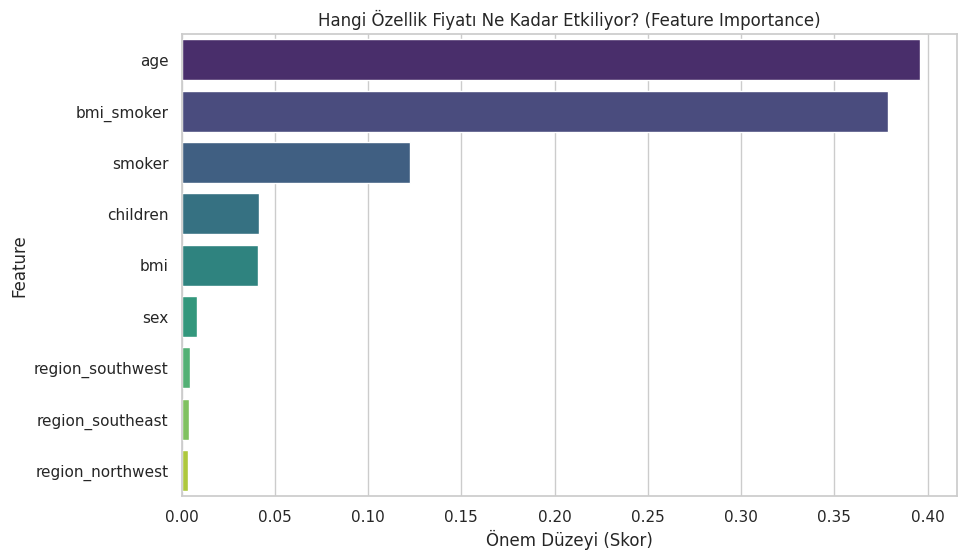

In [21]:
# Özellik Önem Düzeyleri (Feature Importance)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Modelden önem skorlarını al
importances = best_rf_model.feature_importances_
feature_names = X.columns

# DataFrame'e çevir ve sırala
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title('Hangi Özellik Fiyatı Ne Kadar Etkiliyor? (Feature Importance)')
plt.xlabel('Önem Düzeyi (Skor)')
plt.show()

# **SHAP Analizi**

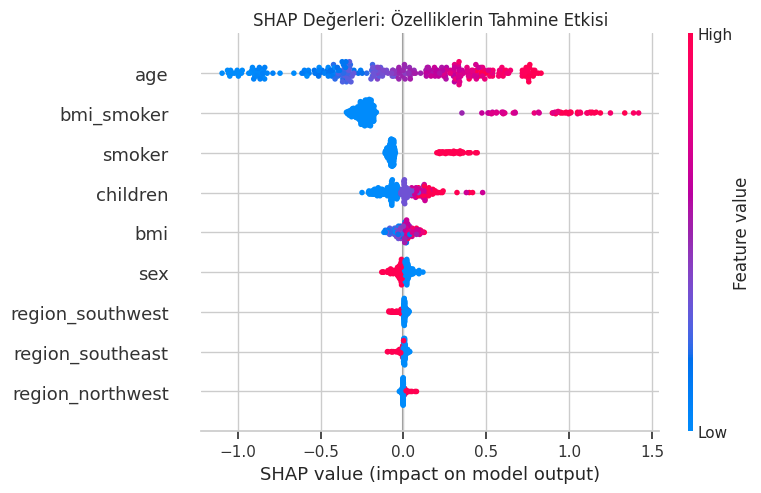

In [22]:
import shap

# SHAP Explainer oluştur
explainer = shap.TreeExplainer(best_rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# Özet Grafik (Beeswarm Plot)
plt.title("SHAP Değerleri: Özelliklerin Tahmine Etkisi")
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

In [23]:
import joblib

# En iyi modeli kaydet
joblib.dump(best_rf_model, 'insurance_model_rf.pkl')

# Scaler'ı kaydet
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']